In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
pip install tensorflow keras opencv-python scikit-image imutils

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def order_points(pts):
    # Order: top-left, top-right, bottom-right, bottom-left
    rect = np.zeros((4, 2), dtype='float32')

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # Top-left
    rect[2] = pts[np.argmax(s)]  # Bottom-right

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # Top-right
    rect[3] = pts[np.argmax(diff)]  # Bottom-left

    return rect


def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # Compute width
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = max(int(widthA), int(widthB))

    # Compute height
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = max(int(heightA), int(heightB))

    # Destination points
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype='float32')

    # Perspective transform
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    return warped

In [3]:
import cv2
import numpy as np


def deskew(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Invert colors
    gray = cv2.bitwise_not(gray)

    # Threshold
    thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY | cv2.THRESH_OTSU
    )[1]

    # Find coordinates of all non-zero pixels
    coords = np.column_stack(np.where(thresh > 0))

    # Compute rotated bounding box angle
    angle = cv2.minAreaRect(coords)[-1]

    # Adjust angle
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    # Rotate image
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        image,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated, angle

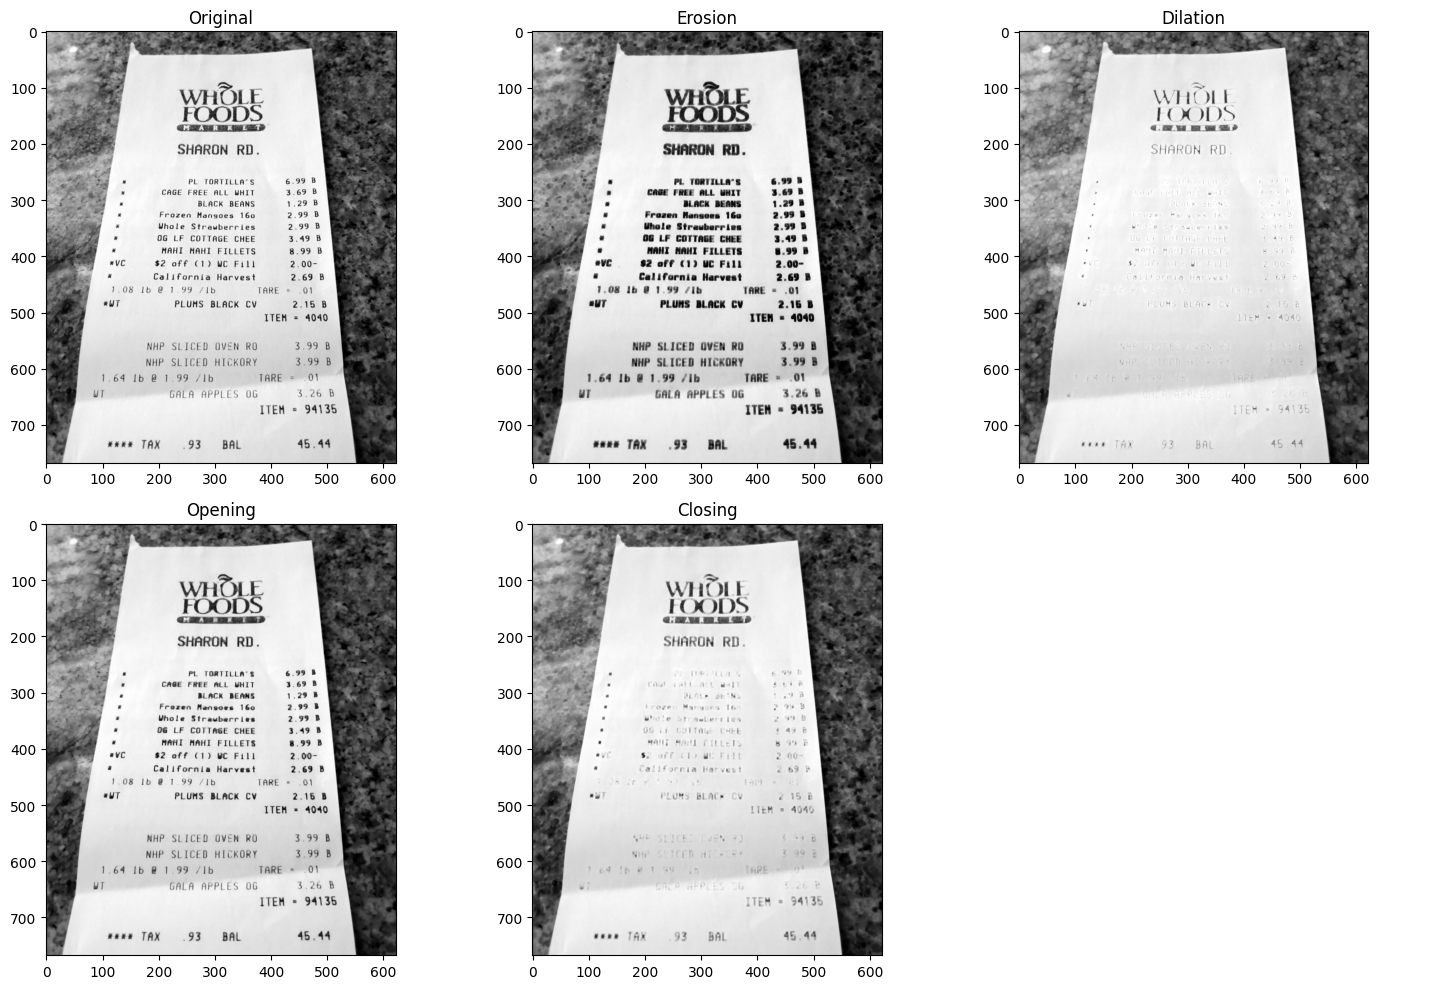

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/images/11.jpg')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Define kernel
kernel = np.ones((3, 3), np.uint8)

# Erosion - remove noise
erosion = cv2.erode(gray, kernel, iterations=1)

# Dilation - fill gaps
dilation = cv2.dilate(gray, kernel, iterations=1)

# Opening - remove small noise
opening = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)

# Closing - fill small holes
closing = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

# Display all results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title('Original')

axes[0, 1].imshow(erosion, cmap='gray')
axes[0, 1].set_title('Erosion')

axes[0, 2].imshow(dilation, cmap='gray')
axes[0, 2].set_title('Dilation')

axes[1, 0].imshow(opening, cmap='gray')
axes[1, 0].set_title('Opening')

axes[1, 1].imshow(closing, cmap='gray')
axes[1, 1].set_title('Closing')

# Hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [12]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data(path="/kaggle/input/datasets/hojjatk/mnist-dataset")

print("Loaded from cache!")

ValueError: Paths are no longer accepted as the `fname` argument. To specify the file's parent directory, use the `cache_dir` argument. Received: fname=/kaggle/input/datasets/hojjatk/mnist-dataset

In [15]:
import numpy as np
import struct

# Load images
def load_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

# Load labels
def load_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


# Path (change if needed)
base_path = "/kaggle/input/datasets/hojjatk/mnist-dataset/"

x_train = load_images(base_path + "train-images.idx3-ubyte")
y_train = load_labels(base_path + "train-labels.idx1-ubyte")

x_test = load_images(base_path + "t10k-images.idx3-ubyte")
y_test = load_labels(base_path + "t10k-labels.idx1-ubyte")

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (60000, 28, 28, 1) (60000,)
Test: (10000, 28, 28, 1) (10000,)


In [16]:
from tensorflow import keras

# Reshape to add channel dimension (for CNN)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Normalize to 0-1 (IMPORTANT: must assign back)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical (one-hot encoding)
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [17]:
from tensorflow import keras
from tensorflow.keras import layers

# Create model
model = keras.Sequential([

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer (10 classes for MNIST digits)
    layers.Dense(10, activation='softmax')
])

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-29 06:57:20.203076: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)

print(f'Test accuracy: {test_acc:.4f}')

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.2265 - loss: 2.0714 - val_accuracy: 0.8585 - val_loss: 0.4960
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.7835 - loss: 0.6779 - val_accuracy: 0.9020 - val_loss: 0.3238
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.8307 - loss: 0.5323 - val_accuracy: 0.9307 - val_loss: 0.2425
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.8584 - loss: 0.4529 - val_accuracy: 0.9445 - val_loss: 0.1959
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.8814 - loss: 0.3872 - val_accuracy: 0.9540 - val_loss: 0.1655
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.8977 - loss: 0.3355 - val_accuracy: 0.9627 - val_loss: 0.1367
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.9121 - loss: 0.2930 - val_accuracy: 0.9665 - val_loss: 0.1191
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.9228 - loss: 0.2558 - 